In [1]:
# Import dependencies

import pandas as pd

import matplotlib.pyplot as plt

import numpy as np


In [2]:
# Create a set of random latitude and longitude combinations.

lats = np.random.uniform(low=-90.000, high=90.000, size = 1500)

lngs = np.random.uniform(low=-90.000, high=90.000, size = 1500)

lat_lngs = zip(lats, lngs)

lat_lngs

In [3]:
# Add the latitudes and longitudes to a list.

coordinates = list(lat_lngs)
coordinates

[(71.82280585877714, -82.70900003175034),
 (45.04105080059935, -24.177982434804264),
 (-62.78712700930767, 28.742242444721583),
 (-18.898047047115284, -44.66906262819314),
 (81.50225370002892, 83.01555520326121),
 (-19.700725019639208, 22.27516740420461),
 (85.71009092730176, 36.150134978353236),
 (-36.45430874752801, 28.779109747265906),
 (82.51269629440992, -77.89480369228245),
 (27.456685528049817, -71.54270448425612),
 (48.49616811574319, -51.22373699483594),
 (6.012893237508649, 74.67174835533513),
 (-35.78200884022909, 52.95023385578622),
 (-80.19175159755234, -57.675521463280816),
 (62.35433359322738, 3.2742691730368847),
 (75.35931760774272, 66.79449453764641),
 (68.24665248758114, -26.65556301109197),
 (27.181720087093126, 8.010452423859618),
 (-12.001398281439691, -8.47103645531169),
 (77.5551626293952, -22.28154095719279),
 (26.43855458693625, -39.08530140935759),
 (-32.35299939935786, 53.830930374465055),
 (-47.05284288733946, -37.841774484103354),
 (-12.127723708176234, 26

In [4]:
from citipy import citipy


In [5]:
# Create a list fo holding the cities.

cities = []

# Identify the nearest city for each latitude and longitude combination.

for coordinate in coordinates:
    
    city = citipy.nearest_city(coordinate[0], coordinate[1]).city_name
    
    # If the city is unique, then we will add it to the cities list.
    
    if city not in cities:
        
        cities.append(city)
        
# Print the city count to confirm sufficient count.

len(cities)
    
    

604

In [6]:
# Import the requests library.

import requests

# Import the API key.

from config import weather_api_key

In [7]:
# Import the time library and the datetime module from the datetime library.

import time

from datetime import datetime

In [8]:
# Start URL for Weather Map API Call.

url = "https://api.openweathermap.org/data/2.5/weather?units=Imperal&APPID=" + weather_api_key

In [9]:
# Create and empty list to hold hte weather data.

city_data = []

# Print the beginning of the logging.

print("Beginning Data Retrieval      ")
print("------------------------------")

# Create counters.

record_count = 1
set_count = 1


# Loop through all the cities in the list.

for i, city in enumerate(cities):
    
    
    # Group cities in sets of 50 for logging purposes
    
    if (i % 50 == 0 and i >= 50):
        
        set_count += 1
        
        record_count = 1
        
        time.sleep(60)
        
        
    # Create endpoint URL with each city.
    
    city_url = url + "&q=" + city.replace(" ", "+")
    
    
    # Log the URL, record, and set numbers and the city.
    
    print(f"Processing Record {record_count} of Set {set_count} | {city}")
    
    # Add 1 to the record count.
    
    record_count +=1
    
    # Run an API request for each of the cities.
    
    try:
        # Parse out the JSON and retrieve data.
        
        city_weather = requests.get(city_url).json()
        
        # Parse out the needed data.
        city_lat = city_weather["coord"]["lat"]
        city_lng = city_weather["coord"]["lon"]
        city_max_temp = city_weather["main"]["temp_max"]
        city_humidity = city_weather["main"]["humidity"]
        city_clouds = city_weather["clouds"]["all"]
        city_wind = city_weather["wind"]["speed"]
        city_country = city_weather["sys"]["country"]
        city_date = datetime.utcfromtimestamp(city_weather["dt"]).strftime('%Y-%m-%d %H:%M:%S') 

        # Append the City information into city_data list
        city_data.append({"City": city.title(), 
                          "Lat": city_lat, 
                          "Lng": city_lng, 
                          "Max Temp": city_max_temp,
                          "Humidity": city_humidity,
                          "Cloudiness": city_clouds,
                          "Wind Speed": city_wind,
                          "Country": city_country,
                          "Date": city_date})
    
    except:
        print('City not found. Skipping....')
        pass
# Indicate that Data Loading is complete.
                                              
print("------------------------------")
print("Data Retrieval Complete.      ")
print("------------------------------")

Beginning Data Retrieval      
------------------------------
Processing Record 1 of Set 1 | clyde river
Processing Record 2 of Set 1 | praia da vitoria
Processing Record 3 of Set 1 | port elizabeth
Processing Record 4 of Set 1 | curvelo
Processing Record 5 of Set 1 | dikson
Processing Record 6 of Set 1 | nokaneng
Processing Record 7 of Set 1 | vardo
Processing Record 8 of Set 1 | port alfred
Processing Record 9 of Set 1 | qaanaaq
Processing Record 10 of Set 1 | cockburn town
Processing Record 11 of Set 1 | torbay
Processing Record 12 of Set 1 | manadhoo
Processing Record 13 of Set 1 | taolanaro
City not found. Skipping....
Processing Record 14 of Set 1 | ushuaia
Processing Record 15 of Set 1 | floro
Processing Record 16 of Set 1 | amderma
City not found. Skipping....
Processing Record 17 of Set 1 | bolungarvik
City not found. Skipping....
Processing Record 18 of Set 1 | gat
Processing Record 19 of Set 1 | jamestown
Processing Record 20 of Set 1 | illoqqortoormiut
City not found. Skipp

Processing Record 32 of Set 4 | santa cruz de la palma
Processing Record 33 of Set 4 | brae
Processing Record 34 of Set 4 | kilindoni
Processing Record 35 of Set 4 | strezhevoy
Processing Record 36 of Set 4 | guane
Processing Record 37 of Set 4 | mogadishu
Processing Record 38 of Set 4 | nuuk
Processing Record 39 of Set 4 | rambha
Processing Record 40 of Set 4 | okahandja
Processing Record 41 of Set 4 | lebu
Processing Record 42 of Set 4 | metu
Processing Record 43 of Set 4 | montauban
Processing Record 44 of Set 4 | coquimbo
Processing Record 45 of Set 4 | chapais
Processing Record 46 of Set 4 | aflu
City not found. Skipping....
Processing Record 47 of Set 4 | scalea
Processing Record 48 of Set 4 | buritis
Processing Record 49 of Set 4 | saint-joseph
Processing Record 50 of Set 4 | ambodifototra
City not found. Skipping....
Processing Record 1 of Set 5 | paita
Processing Record 2 of Set 5 | mehamn
Processing Record 3 of Set 5 | khorramshahr
Processing Record 4 of Set 5 | san andres
Pr

Processing Record 23 of Set 8 | canutama
Processing Record 24 of Set 8 | padang
Processing Record 25 of Set 8 | ancud
Processing Record 26 of Set 8 | mafeteng
Processing Record 27 of Set 8 | garwa
Processing Record 28 of Set 8 | fez
Processing Record 29 of Set 8 | stutterheim
Processing Record 30 of Set 8 | umzimvubu
City not found. Skipping....
Processing Record 31 of Set 8 | karaul
City not found. Skipping....
Processing Record 32 of Set 8 | johi
Processing Record 33 of Set 8 | husavik
Processing Record 34 of Set 8 | sinnamary
Processing Record 35 of Set 8 | danilovka
Processing Record 36 of Set 8 | cowie
Processing Record 37 of Set 8 | novyy svit
Processing Record 38 of Set 8 | pervomayskiy
Processing Record 39 of Set 8 | alibag
Processing Record 40 of Set 8 | alexandria
Processing Record 41 of Set 8 | lerwick
Processing Record 42 of Set 8 | port blair
Processing Record 43 of Set 8 | teterow
Processing Record 44 of Set 8 | mopti
Processing Record 45 of Set 8 | gazanjyk
Processing Re

Processing Record 10 of Set 12 | kamenka
Processing Record 11 of Set 12 | keetmanshoop
Processing Record 12 of Set 12 | mindelo
Processing Record 13 of Set 12 | westport
Processing Record 14 of Set 12 | asfi
Processing Record 15 of Set 12 | bayir
Processing Record 16 of Set 12 | odoyev
Processing Record 17 of Set 12 | kegayli
City not found. Skipping....
Processing Record 18 of Set 12 | mananara
Processing Record 19 of Set 12 | rayevskiy
Processing Record 20 of Set 12 | talcahuano
Processing Record 21 of Set 12 | filadelfia
Processing Record 22 of Set 12 | miandrivazo
Processing Record 23 of Set 12 | mirina
City not found. Skipping....
Processing Record 24 of Set 12 | rio verde de mato grosso
Processing Record 25 of Set 12 | maunabo
Processing Record 26 of Set 12 | bria
Processing Record 27 of Set 12 | qaqortoq
Processing Record 28 of Set 12 | chimbote
Processing Record 29 of Set 12 | dunmore east
Processing Record 30 of Set 12 | santana
Processing Record 31 of Set 12 | amanganj
Proces

In [10]:
len(city_data)

552

In [11]:
# Convert the array of dictionaries to a Pandas DataFrame.

city_data_df = pd.DataFrame(city_data)

city_data_df.head(10)

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
0,Clyde River,70.4692,-68.5914,276.27,85,3,2.50,CA,2022-06-18 22:08:08
1,Praia Da Vitoria,38.7333,-27.0667,291.90,77,16,7.22,PT,2022-06-18 22:10:00
2,Port Elizabeth,-33.9180,25.5701,286.54,96,100,0.45,ZA,2022-06-18 22:10:00
3,Curvelo,-18.7564,-44.4308,294.02,42,6,1.09,BR,2022-06-18 22:10:01
4,Dikson,73.5069,80.5464,272.62,86,76,6.19,RU,2022-06-18 22:10:02
5,Nokaneng,-19.6667,22.2667,287.34,32,0,1.43,BW,2022-06-18 22:10:03
6,Vardo,70.3705,31.1107,278.14,87,100,1.03,NO,2022-06-18 22:10:04
7,Port Alfred,-33.5906,26.8910,289.06,81,100,4.12,ZA,2022-06-18 22:10:05
8,Qaanaaq,77.4840,-69.3632,277.16,68,32,2.27,GL,2022-06-18 22:10:06
9,Cockburn Town,21.4612,-71.1419,301.13,74,40,4.63,TC,2022-06-18 22:10:07


In [12]:
# Rearrange columns.

new_column_order = ["City", "Country", "Date", "Lat", "Lng", "Max Temp", "Humidity", "Cloudiness", "Wind Speed"]

city_data_df = city_data_df[new_column_order]

city_data_df.head(10)

,City,Country,Date,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed
0,Clyde River,CA,2022-06-18 22:08:08,70.4692,-68.5914,276.27,85,3,2.50
1,Praia Da Vitoria,PT,2022-06-18 22:10:00,38.7333,-27.0667,291.90,77,16,7.22
2,Port Elizabeth,ZA,2022-06-18 22:10:00,-33.9180,25.5701,286.54,96,100,0.45
3,Curvelo,BR,2022-06-18 22:10:01,-18.7564,-44.4308,294.02,42,6,1.09
4,Dikson,RU,2022-06-18 22:10:02,73.5069,80.5464,272.62,86,76,6.19
5,Nokaneng,BW,2022-06-18 22:10:03,-19.6667,22.2667,287.34,32,0,1.43
6,Vardo,NO,2022-06-18 22:10:04,70.3705,31.1107,278.14,87,100,1.03
7,Port Alfred,ZA,2022-06-18 22:10:05,-33.5906,26.8910,289.06,81,100,4.12
8,Qaanaaq,GL,2022-06-18 22:10:06,77.4840,-69.3632,277.16,68,32,2.27
9,Cockburn Town,TC,2022-06-18 22:10:07,21.4612,-71.1419,301.13,74,40,4.63


In [13]:
# Create the outpute file (CSV).

output_data_file = "weather_data/cities.csv"

# Export the City_Data into a CSV.

city_data_df.to_csv(output_data_file, index_label="City_ID")

In [17]:
# Extract relevant fields from the DataFrame for plotting.

lats = city_data_df["Lat"]

max_temps = city_data_df["Max Temp"]

humidity = city_data_df["Humidity"]

cloudiness = city_data_df["Cloudiness"]

wind_speed = city_data_df["Wind Speed"]

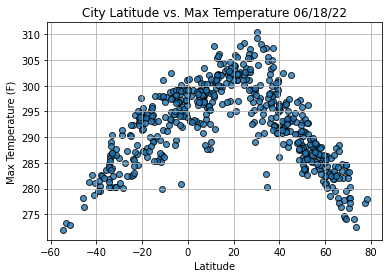

In [18]:
# Import time module.

import time

# Build the scatter plot for latitude vs. max temperature.

plt.scatter(lats,
           max_temps,
           edgecolor="black", linewidths=1, marker="o",
           alpha=0.8, label="Cities")

# Incorporate the other graph properties.

plt.title(f"City Latitude vs. Max Temperature "+ time.strftime('%x'))

plt.ylabel("Max Temperature (F)")

plt.xlabel("Latitude")

plt.grid(True)


# Save the figure.

plt.savefig("weather_data/Fig1.png")


# Show plot.

plt.show()

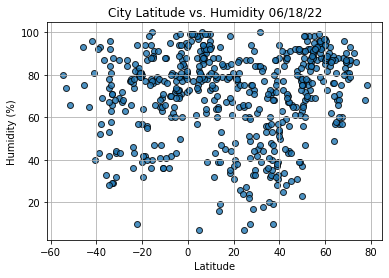

In [19]:
# Build the scatter plots for latitude vs. humidity.
plt.scatter(lats,
            humidity,
            edgecolor="black", linewidths=1, marker="o",
            alpha=0.8, label="Cities")

# Incorporate the other graph properties.
plt.title(f"City Latitude vs. Humidity "+ time.strftime("%x"))
plt.ylabel("Humidity (%)")
plt.xlabel("Latitude")
plt.grid(True)
# Save the figure.
plt.savefig("weather_data/Fig2.png")
# Show plot.
plt.show()

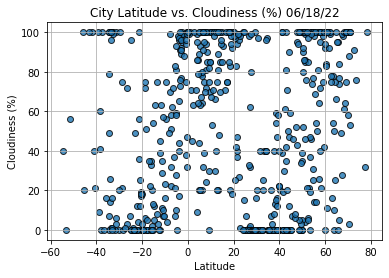

In [20]:
# Build the scatter plots for latitude vs. humidity.
plt.scatter(lats,
            cloudiness,
            edgecolor="black", linewidths=1, marker="o",
            alpha=0.8, label="Cities")

# Incorporate the other graph properties.
plt.title(f"City Latitude vs. Cloudiness (%) "+ time.strftime("%x"))
plt.ylabel("Cloudiness (%)")
plt.xlabel("Latitude")
plt.grid(True)
# Save the figure.
plt.savefig("weather_data/Fig3.png")
# Show plot.
plt.show()

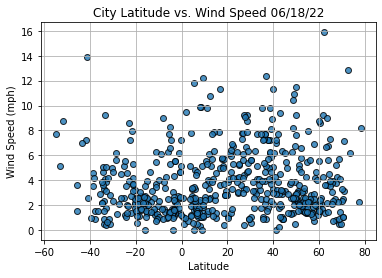

In [21]:
# Build the scatter plots for latitude vs. humidity.
plt.scatter(lats,
            wind_speed,
            edgecolor="black", linewidths=1, marker="o",
            alpha=0.8, label="Cities")

# Incorporate the other graph properties.
plt.title(f"City Latitude vs. Wind Speed "+ time.strftime("%x"))
plt.ylabel("Wind Speed (mph)")
plt.xlabel("Latitude")
plt.grid(True)
# Save the figure.
plt.savefig("weather_data/Fig4.png")
# Show plot.
plt.show()